<a href="https://colab.research.google.com/github/matteuscruz/irc_vendaval/blob/main/IRB_DATA_EXPLORERR_LCUSTER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First, we need to import the `pandas` library to handle data loading and manipulation. Then, we'll load the data from the specified path into a DataFrame and display its first 5 rows to get a quick overview.

In [ ]:
import pandas as pd
import xarray as xr

# Define the path to your dataset
data_path = '/content/drive/MyDrive/- IRB/Vendaval-IA/dataset/raw'

# Attempt to read a data file from the path. If your file is a different type, please let me know.
# To list files in the directory and then choose one:
import os
files_in_dir = os.listdir(data_path)
print(f"Files found in '{data_path}': {files_in_dir}")

# Let's try to load the first NetCDF (.nc) file we find, as detected previously.
nc_files = [f for f in files_in_dir if f.endswith('.nc')]
if nc_files:
    first_nc_file = nc_files[0]
    full_file_path = os.path.join(data_path, first_nc_file)
    print(f"Attempting to load NetCDF file: {full_file_path}")
    try:
        ds = xr.open_dataset(full_file_path)
        print("NetCDF data loaded successfully!")
        display(ds) # Display the xarray Dataset
    except Exception as e:
        print(f"Error loading NetCDF file: {e}")
        print("Please ensure the file is a valid NetCDF or specify the correct file type and name.")
elif [f for f in files_in_dir if f.endswith('.csv')]:
    # Fallback to CSV loading if .nc files are not found but .csv files exist (though this was handled earlier)
    csv_files = [f for f in files_in_dir if f.endswith('.csv')]
    first_csv_file = csv_files[0]
    full_file_path = os.path.join(data_path, first_csv_file)
    print(f"Attempting to load CSV file: {full_file_path}")
    try:
        df = pd.read_csv(full_file_path)
        print("CSV data loaded successfully!")
        display(df.head())
    except Exception as e:
        print(f"Error loading CSV file: {e}")
        print("Please ensure the file is a valid CSV or specify the correct file type and name.")
else:
    print("No recognizable data files (.nc or .csv) found in the specified directory. Please specify the exact file name and type.")


Files found in '/content/drive/MyDrive/- IRB/Vendaval-IA/dataset/raw': ['INMET_Stratified.nc', 'ERA5_Stratified.nc']
Attempting to load NetCDF file: /content/drive/MyDrive/- IRB/Vendaval-IA/dataset/raw/INMET_Stratified.nc
NetCDF data loaded successfully!


<xarray.Dataset> Size: 1MB
Dimensions:                           (time: 1827, estacao: 30)
Coordinates:
  * time                              (time) datetime64[ns] 15kB 2020-01-01 ....
  * estacao                           (estacao) <U4 480B 'A894' ... 'A802'
    latitude                          (estacao) float64 240B ...
    longitude                         (estacao) float64 240B ...
Data variables:
    daily_wind_gust_max               (time, estacao) float64 438kB ...
    daily_wind_speed_mean             (time, estacao) float64 438kB ...
    daily_wind_direction_at_gust_max  (time, estacao) float64 438kB ...

### Carregando ambos os conjuntos de dados (INMET e ERA5)

Para realizar uma análise agregada, precisamos carregar os dois arquivos NetCDF identificados anteriormente no diretório.

In [ ]:
import xarray as xr
import os

# Caminhos completos para os arquivos
inmet_path = os.path.join(data_path, 'INMET_Stratified.nc')
era5_path = os.path.join(data_path, 'ERA5_Stratified.nc')

# Carregando os datasets
ds_inmet = xr.open_dataset(inmet_path)
ds_era5 = xr.open_dataset(era5_path)

print("Dataset INMET carregado:")
display(ds_inmet)

print("\nDataset ERA5 carregado:")
display(ds_era5)

Dataset INMET carregado:


<xarray.Dataset> Size: 1MB
Dimensions:                           (time: 1827, estacao: 30)
Coordinates:
  * time                              (time) datetime64[ns] 15kB 2020-01-01 ....
  * estacao                           (estacao) <U4 480B 'A894' ... 'A802'
    latitude                          (estacao) float64 240B ...
    longitude                         (estacao) float64 240B ...
Data variables:
    daily_wind_gust_max               (time, estacao) float64 438kB ...
    daily_wind_speed_mean             (time, estacao) float64 438kB ...
    daily_wind_direction_at_gust_max  (time, estacao) float64 438kB ...


Dataset ERA5 carregado:


<xarray.Dataset> Size: 388MB
Dimensions:                  (time: 229991, estacao: 30)
Coordinates:
  * time                     (time) datetime64[ns] 2MB 2000-01-01 ... 2026-03...
  * estacao                  (estacao) <U4 480B 'A894' 'A809' ... 'A812' 'A802'
    latitude                 (estacao) float64 240B ...
    longitude                (estacao) float64 240B ...
Data variables:
    10m_u_component_of_wind  (time, estacao) float64 55MB ...
    10m_v_component_of_wind  (time, estacao) float64 55MB ...
    2m_dewpoint_temperature  (time, estacao) float64 55MB ...
    2m_temperature           (time, estacao) float64 55MB ...
    mean_sea_level_pressure  (time, estacao) float64 55MB ...
    surface_pressure         (time, estacao) float64 55MB ...
    total_precipitation      (time, estacao) float64 55MB ...

### Agregação Espaço-Temporal

Agora vamos calcular a média da velocidade do vento (`daily_wind_speed_mean`) para ambos os datasets, agregando por tempo (média diária geral) e por estação/localização.

In [ ]:
import numpy as np

# Para o INMET, usamos a variável existente
inmet_wind = ds_inmet['daily_wind_speed_mean']

# Para o ERA5, calculamos a magnitude da velocidade a partir dos componentes u e v
era5_wind = np.sqrt(ds_era5['10m_u_component_of_wind']**2 + ds_era5['10m_v_component_of_wind']**2)
era5_wind.name = 'wind_speed'

# Média temporal (média de todas as estações por dia)
inmet_time_series = inmet_wind.mean(dim='estacao')
era5_time_series = era5_wind.mean(dim='estacao')

# Média espacial (média de todo o período por estação)
inmet_spatial = inmet_wind.mean(dim='time')
era5_spatial = era5_wind.mean(dim='time')

print("Médias calculadas com sucesso para ambos os datasets (ERA5 calculado via componentes u/v).")

Médias calculadas com sucesso para ambos os datasets (ERA5 calculado via componentes u/v).


To visualize the data spatially, let's plot the average wind speed at each station. We'll use the `latitude` and `longitude` coordinates available in the dataset for each station and color-code the points based on their average wind speed over the entire period.

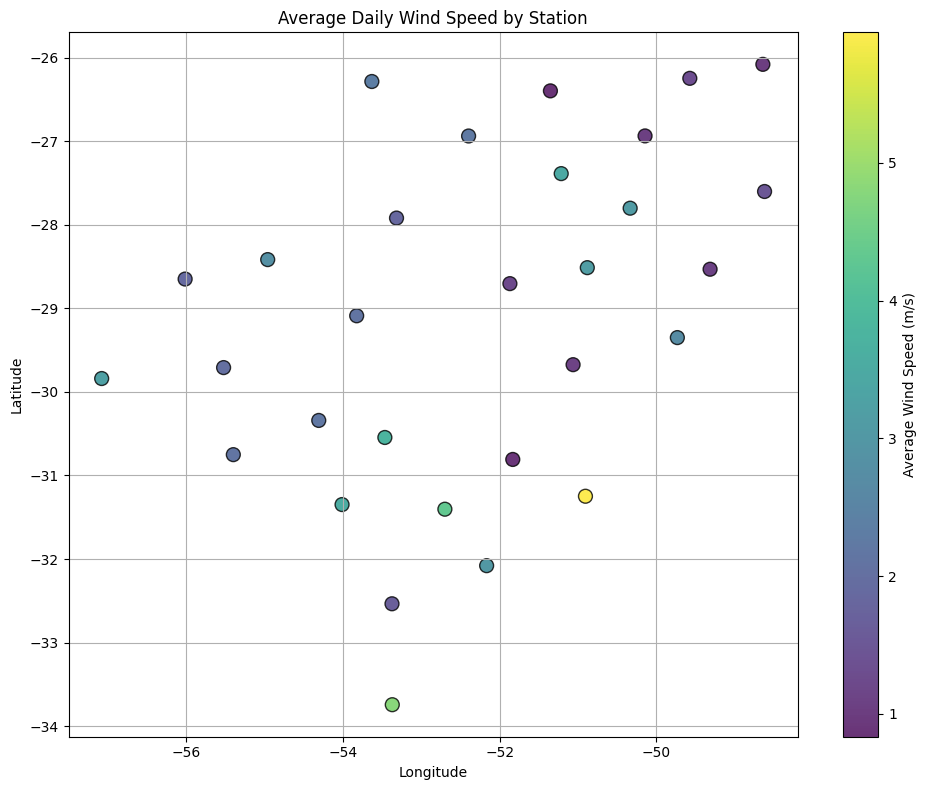

In [ ]:
import matplotlib.pyplot as plt

# Calculate the mean of 'daily_wind_speed_mean' for each station over the entire time period
average_wind_speed_per_station = ds['daily_wind_speed_mean'].mean(dim='time')

# Get the latitude and longitude for each station
# These coordinates are constant for each station, so we access them directly.
station_latitudes = ds['latitude']
station_longitudes = ds['longitude']

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    station_longitudes.values,
    station_latitudes.values,
    c=average_wind_speed_per_station.values,
    cmap='viridis', # Colormap for wind speed
    s=100,          # Size of points
    edgecolors='black', # Black border for points
    alpha=0.8       # Transparency
)

plt.colorbar(scatter, label='Average Wind Speed (m/s)')
plt.title('Average Daily Wind Speed by Station')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.tight_layout()
plt.show()


To add the state boundaries of Brazil, we'll use the `geopandas` library. We'll install it first, then load a GeoJSON file with the state shapes, and finally overlay these shapes on our existing plot.

In [ ]:
# Install geopandas. This may take a moment.
!pip install geopandas matplotlib-scalebar

# Import necessary libraries
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar

In [ ]:
# Load Brazilian state boundaries from a GeoJSON file
# This is a public GeoJSON for Brazilian states, often used for visualization.
brazil_states_gdf = gpd.read_file("https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson")

print("Brazilian state boundaries loaded successfully!")


Brazilian state boundaries loaded successfully!


Now, let's modify the previous cell to incorporate these state boundaries into the spatial plot. We'll plot the state boundaries first, and then overlay our station data on top.

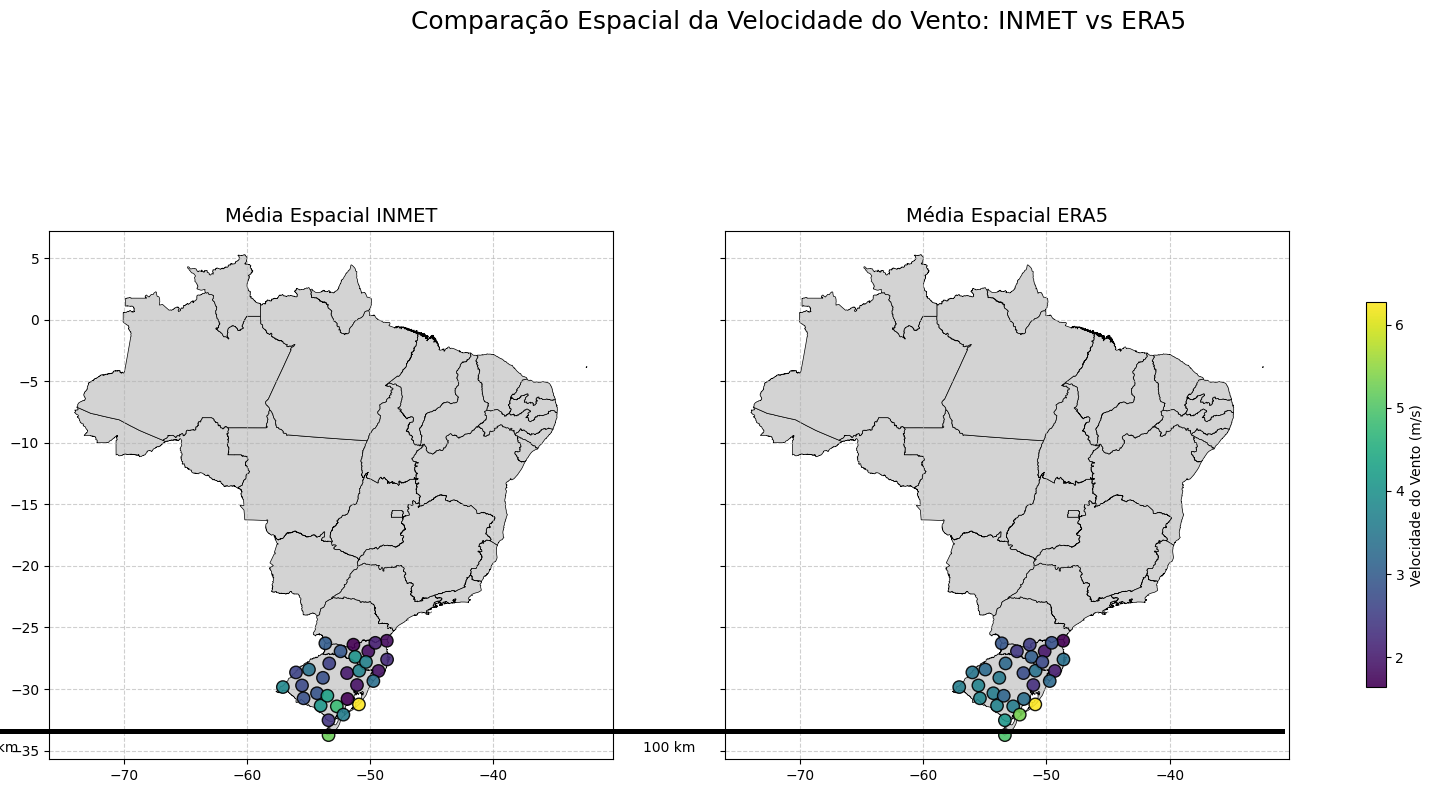

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib_scalebar.scalebar import ScaleBar

# Criando dois subplots para comparação espacial (INMET vs ERA5)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), sharey=True)

# Lista de datasets agregados e títulos para o loop
plot_configs = [
    (ax1, inmet_spatial, 'Média Espacial INMET'),
    (ax2, era5_spatial, 'Média Espacial ERA5')
]

for ax, data, title in plot_configs:
    # Plotar fronteiras dos estados do Brasil
    brazil_states_gdf.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.5)

    # Plotar os pontos das estações
    # Usamos as coordenadas do dataset INMET que são as mesmas para as estações fixas
    scatter = ax.scatter(
        ds_inmet['longitude'].values,
        ds_inmet['latitude'].values,
        c=data.values,
        cmap='viridis',
        s=80,
        edgecolors='black',
        alpha=0.9,
        zorder=5
    )

    ax.set_title(title, fontsize=14)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.6)

    # Adicionar barra de escala
    scalebar = ScaleBar(dx=1, units='km', location='lower right', frameon=False, fixed_value=100, rotation='horizontal-only')
    ax.add_artist(scalebar)

# Adicionar uma barra de cores única para ambos os plots
fig.colorbar(scatter, ax=[ax1, ax2], label='Velocidade do Vento (m/s)', orientation='vertical', shrink=0.5)

plt.suptitle('Comparação Espacial da Velocidade do Vento: INMET vs ERA5', fontsize=18)
plt.show()

### Verificação de Consistência dos Dados

Vamos validar se os shapes e as coordenadas de tempo/estação estão alinhados entre os datasets do INMET e ERA5 para garantir que a comparação seja justa.

In [ ]:
# Verificando as dimensões dos datasets originais
print(f"Dimensões INMET: {ds_inmet.dims}")
print(f"Dimensões ERA5:  {ds_era5.dims}")

# Verificando se o período temporal coincide
time_start_inmet = ds_inmet.time.min().values
time_end_inmet = ds_inmet.time.max().values
time_start_era5 = ds_era5.time.min().values
time_end_era5 = ds_era5.time.max().values

print(f"\nPeríodo INMET: {time_start_inmet} até {time_end_inmet}")
print(f"Período ERA5:  {time_start_era5} até {time_end_era5}")

# Verificando se o número de estações coincide
print(f"\nNúmero de estações (INMET): {len(ds_inmet.estacao)}")
print(f"Número de estações (ERA5):  {len(ds_era5.estacao)}")

# Checando por valores nulos (NaN) nas variáveis de vento principais
nan_inmet = ds_inmet['daily_wind_speed_mean'].isnull().sum().values
nan_era5 = (ds_era5['10m_u_component_of_wind'].isnull().sum() + ds_era5['10m_v_component_of_wind'].isnull().sum()).values

print(f"\nValores NaN no INMET: {nan_inmet}")
print(f"Valores NaN no ERA5 (componentes u/v): {nan_era5}")

Dimensões INMET: FrozenMappingWarningOnValuesAccess({'time': 1827, 'estacao': 30})
Dimensões ERA5:  FrozenMappingWarningOnValuesAccess({'time': 229991, 'estacao': 30})

Período INMET: 2020-01-01T00:00:00.000000000 até 2024-12-31T00:00:00.000000000
Período ERA5:  2000-01-01T00:00:00.000000000 até 2026-03-27T22:00:00.000000000

Número de estações (INMET): 30
Número de estações (ERA5):  30

Valores NaN no INMET: 6155
Valores NaN no ERA5 (componentes u/v): 1560


### Alinhamento Temporal e Tratamento de Dados Faltantes

Como o ERA5 possui uma janela temporal muito maior e o INMET possui valores nulos, vamos realizar o alinhamento para que a comparação seja feita exatamente no mesmo período e locais.

In [ ]:
import pandas as pd

# 1. Alinhar o ERA5 ao período do INMET
ds_era5_aligned = ds_era5.sel(time=slice(ds_inmet.time.min(), ds_inmet.time.max()))

# 2. Resampler o ERA5 para média diária (caso seja horário)
ds_era5_daily = ds_era5_aligned.resample(time='1D').mean()

# 3. Calcular a magnitude do vento para o ERA5 diário
era5_wind_daily = np.sqrt(ds_era5_daily['10m_u_component_of_wind']**2 + ds_era5_daily['10m_v_component_of_wind']**2)
era5_wind_daily.name = 'wind_speed_era5'

# 4. Sincronizar NaNs: Onde o INMET é NaN, o ERA5 também deve ser ignorado para comparação justa
inmet_wind = ds_inmet['daily_wind_speed_mean']
era5_wind_masked = era5_wind_daily.where(~inmet_wind.isnull())

print(f"Novas dimensões ERA5 (diário/alinhado): {era5_wind_masked.dims}")
print(f"Valores NaN sincronizados no ERA5: {era5_wind_masked.isnull().sum().values}")

Novas dimensões ERA5 (diário/alinhado): ('time', 'estacao')
Valores NaN sincronizados no ERA5: 6155


## Análise Exploratória de Dados (EDA): INMET vs ERA5

Agora que os dados estão alinhados, vamos comparar o comportamento estatístico das duas fontes de dados.

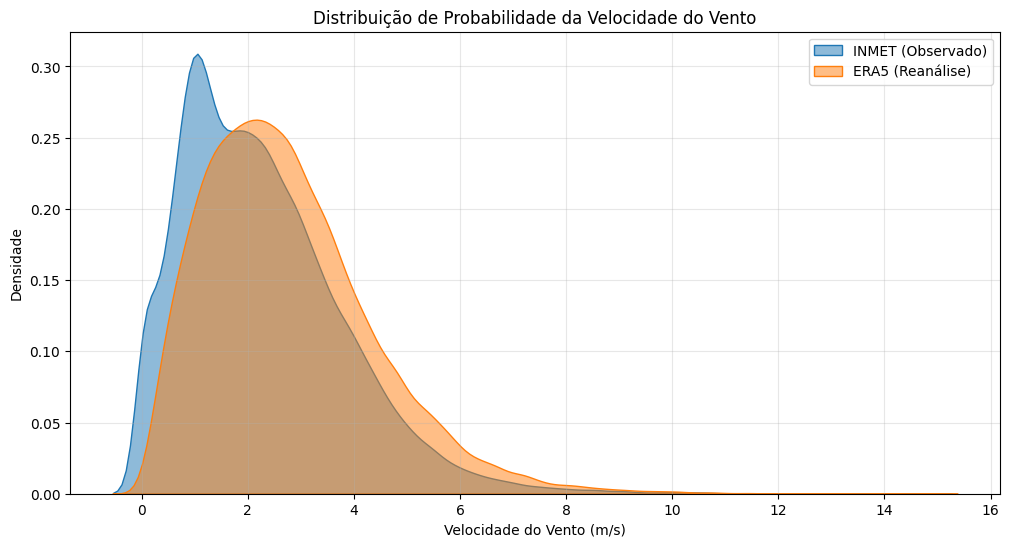

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

# 1. Distribuição Global das Velocidades
plt.figure(figsize=(12, 6))
sns.kdeplot(inmet_wind.values.flatten(), label='INMET (Observado)', fill=True, alpha=0.5)
sns.kdeplot(era5_wind_masked.values.flatten(), label='ERA5 (Reanálise)', fill=True, alpha=0.5)
plt.title('Distribuição de Probabilidade da Velocidade do Vento')
plt.xlabel('Velocidade do Vento (m/s)')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

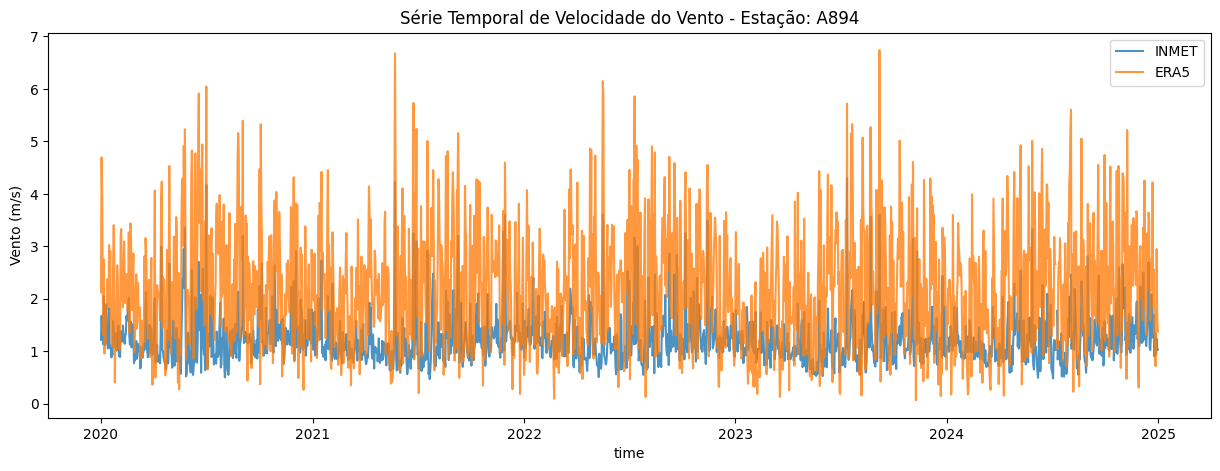

In [ ]:
# 2. Comparação Temporal em uma Estação Aleatória
estacao_idx = 0
estacao_nome = ds_inmet.estacao.values[estacao_idx]

plt.figure(figsize=(15, 5))
inmet_wind.isel(estacao=estacao_idx).plot(label='INMET', alpha=0.8)
era5_wind_masked.isel(estacao=estacao_idx).plot(label='ERA5', alpha=0.8)
plt.title(f'Série Temporal de Velocidade do Vento - Estação: {estacao_nome}')
plt.ylabel('Vento (m/s)')
plt.legend()
plt.show()

In [ ]:
# 3. Métricas de Correlação e Erro
# Remover NaNs para cálculo das métricas
mask = ~np.isnan(inmet_wind.values.flatten()) & ~np.isnan(era5_wind_masked.values.flatten())
y_true = inmet_wind.values.flatten()[mask]
y_pred = era5_wind_masked.values.flatten()[mask]

corr = np.corrcoef(y_true, y_pred)[0, 1]
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
bias = np.mean(y_pred - y_true)

print(f"--- Métricas Globais (Alinhadas) ---")
print(f"Correlação de Pearson: {corr:.3f}")
print(f"RMSE: {rmse:.3f} m/s")
print(f"Bias (ERA5 - INMET): {bias:.3f} m/s")

--- Métricas Globais (Alinhadas) ---
Correlação de Pearson: 0.592
RMSE: 1.514 m/s
Bias (ERA5 - INMET): 0.496 m/s


### Divisão Temporal (Train / Val / Test)

Para evitar vazamento de dados (data leakage), vamos separar os dados cronologicamente:
- **Treino**: 2020 - 2022
- **Validação**: 2023
- **Teste**: 2024

In [ ]:
# Definindo os períodos
train_slice = slice('2020-01-01', '2022-12-31')
val_slice = slice('2023-01-01', '2023-12-31')
test_slice = slice('2024-01-01', '2024-12-31')

# Split para o INMET (Target/Observado)
inmet_train = inmet_wind.sel(time=train_slice)
inmet_val = inmet_wind.sel(time=val_slice)
inmet_test = inmet_wind.sel(time=test_slice)

# Split para o ERA5 (Features/Reanálise)
era5_train = era5_wind_masked.sel(time=train_slice)
era5_val = era5_wind_masked.sel(time=val_slice)
era5_test = era5_wind_masked.sel(time=test_slice)

print(f"Treino: {inmet_train.time.size} dias")
print(f"Validação: {inmet_val.time.size} dias")
print(f"Teste: {inmet_test.time.size} dias")

Treino: 1096 dias
Validação: 365 dias
Teste: 366 dias


### Verificação do Split por Estação

Como os objetos xarray mantêm as coordenadas, cada conjunto (train/val/test) contém os dados de todas as 30 estações. Vamos visualizar o shape para confirmar.

In [ ]:
# Verificando o shape (Tempo, Estação)
print(f"Shape Treino (INMET): {inmet_train.shape}")
print(f"Shape Validação (INMET): {inmet_val.shape}")
print(f"Shape Teste (INMET): {inmet_test.shape}")

# Exemplo de como acessar uma estação específica ('A801' por exemplo, se existir)
# ou apenas a primeira estação pelo índice
nome_primeira_estacao = inmet_train.estacao.values[0]
dados_estacao_0_treino = inmet_train.isel(estacao=0)

print(f"\nDados de treino para a estação {nome_primeira_estacao}: {dados_estacao_0_treino.size} dias")

Shape Treino (INMET): (1096, 30)
Shape Validação (INMET): (365, 30)
Shape Teste (INMET): (366, 30)

Dados de treino para a estação A894: 1096 dias


### Divisão Espacial (Split por Estações)

Nesta etapa, vamos selecionar aleatoriamente (mas com semente fixa para reprodutibilidade) um grupo de estações para compor o conjunto de teste 'não visto' espacialmente.

In [ ]:
import numpy as np

# Definir semente para reprodutibilidade
np.random.seed(42)

# Obter lista de todas as estações
todas_estacoes = ds_inmet.estacao.values
n_total = len(todas_estacoes)

# Selecionar 20% das estações para teste espacial
n_test = int(0.2 * n_total)
estacoes_teste = np.random.choice(todas_estacoes, n_test, replace=False)
estacoes_treino = np.array([s for s in todas_estacoes if s not in estacoes_teste])

print(f"Estações de Treino ({len(estacoes_treino)}): {estacoes_treino}")
print(f"Estações de Teste ({len(estacoes_teste)}): {estacoes_teste}")

# Criando os datasets filtrados espacialmente
ds_train_spatial = inmet_train.sel(estacao=estacoes_treino)
ds_test_spatial = inmet_test.sel(estacao=estacoes_teste)

print(f"\nShape Final Treino (Tempo, Estação): {ds_train_spatial.shape}")
print(f"Shape Final Teste  (Tempo, Estação): {ds_test_spatial.shape}")

Estações de Treino (24): ['A894' 'A809' 'A899' 'A851' 'A848' 'A832' 'A878' 'A814' 'A811' 'A856'
 'A826' 'A861' 'A886' 'A836' 'A806' 'A830' 'A827' 'A804' 'A838' 'A898'
 'A808' 'A862' 'A812' 'A802']
Estações de Teste (6): ['A865' 'A884' 'A880' 'A858' 'A875' 'A852']

Shape Final Treino (Tempo, Estação): (1096, 24)
Shape Final Teste  (Tempo, Estação): (366, 6)


### Ordem Temporal e Timestamps na LSTM

Para responder à sua dúvida: **Sim, a ordem dos dados é preservada.**

A LSTM do Keras espera um input no formato `(batch, timesteps, features)`. No código abaixo:
1.  **Ordenação**: Usamos `df_st.sort_values('time')` para garantir que, para cada estação, os dados estejam em ordem cronológica.
2.  **Janelas (Windowing)**: Criamos sequências de 7 dias consecutivos. O índice `i-window_size:i` garante que o modelo veja o dia 1, depois o dia 2, até o dia 7, antes de prever o alvo.
3.  **Engenharia de Tempo**: Como a LSTM por si só não sabe se 'hoje' é Verão ou Inverno, incluímos as features `day_sin` e `day_cos`. Elas informam ao modelo a posição exata no ciclo anual, ajudando a capturar padrões sazonais de rajadas.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler

# Define the window size for the LSTM model
window_size = 7

def prepare_lstm_data(ds_features, ds_target, target_var='daily_wind_gust_max', window_size=7):
    # 1. Selecionar features do ERA5
    df_feat = ds_features.to_dataframe().reset_index()
    df_targ = ds_target[target_var].to_dataframe().reset_index()

    # Merge e remoção de NaNs - Mantendo a coluna 'time' para ordenação
    df_final = pd.merge(df_feat, df_targ, on=['time', 'estacao'], how='inner').dropna()

    # 2. Engenharia de Features Temporais Cíclicas
    # Transformamos o tempo em sen/cos para que o modelo entenda a continuidade do ciclo anual
    day_of_year = df_final['time'].dt.dayofyear
    df_final['day_sin'] = np.sin(2 * np.pi * day_of_year / 365.25)
    df_final['day_cos'] = np.cos(2 * np.pi * day_of_year / 365.25)

    # Feature de magnitude física do vento
    df_final['wind_mag'] = np.sqrt(df_final['10m_u_component_of_wind']**2 + df_final['10m_v_component_of_wind']**2)

    # Aqui definimos as colunas que o modelo REALMENTE verá (incluindo as temporais)
    features_cols = [
        '10m_u_component_of_wind',
        '10m_v_component_of_wind',
        'wind_mag',
        '2m_temperature',
        'surface_pressure',
        'day_sin',
        'day_cos'  # <--- Features temporais passadas ao modelo
    ]

    # 3. Normalização e Estruturação de Sequências
    scaler_x = RobustScaler()
    scaler_y = RobustScaler()

    X_data, y_data = [], []

    for st in df_final['estacao'].unique():
        df_st = df_final[df_final['estacao'] == st].sort_values('time')
        if len(df_st) < window_size: continue

        st_feat = scaler_x.fit_transform(df_st[features_cols])
        st_targ = scaler_y.fit_transform(df_st[[target_var]])

        for i in range(window_size, len(df_st)):
            X_data.append(st_feat[i-window_size:i])
            y_data.append(st_targ[i])

    return np.array(X_data), np.array(y_data), scaler_x, scaler_y

# Re-preparando os dados para garantir que as novas features temporais sejam incluídas
X_train, y_train, s_x, s_y = prepare_lstm_data(ds_era5_daily.sel(estacao=estacoes_treino, time=train_slice), ds_inmet.sel(estacao=estacoes_treino, time=train_slice), window_size=window_size)
print(f"Dados preparados com features temporais cíclicas: {X_train.shape}")

Dados preparados com features temporais cíclicas: (22924, 7, 7)


### Cálculo da Climatologia e Detrending

Nesta etapa, calculamos a média histórica diária para cada estação no período de treino. Isso servirá como nosso 'ponto zero'.

In [ ]:
def prepare_lstm_seasonal(ds_features, ds_target, ds_clim, window_size=7):
    # Reutiliza a lógica de detrending para criar anomalias
    df_feat = ds_features.to_dataframe().reset_index()
    df_targ = ds_target[['daily_wind_gust_max']].to_dataframe().reset_index()
    df_targ['dayofyear'] = df_targ['time'].dt.dayofyear
    df_clim_df = ds_clim.to_dataframe(name='clim_value').reset_index()

    df_merged = pd.merge(df_feat, df_targ, on=['time', 'estacao'], how='inner')
    df_merged = pd.merge(df_merged, df_clim_df, on=['dayofyear', 'estacao'], how='left')
    df_merged['target_anomaly'] = df_merged['daily_wind_gust_max'] - df_merged['clim_value']
    df_merged = df_merged.dropna().sort_values(['estacao', 'time'])

    # Engenharia de Features
    day_of_year = df_merged['time'].dt.dayofyear
    df_merged['day_sin'] = np.sin(2 * np.pi * day_of_year / 365.25)
    df_merged['day_cos'] = np.cos(2 * np.pi * day_of_year / 365.25)
    df_merged['wind_mag'] = np.sqrt(df_merged['10m_u_component_of_wind']**2 + df_merged['10m_v_component_of_wind']**2)

    # Mapeamento de Estações do Ano
    def get_season(month):
        if month in [12, 1, 2]: return 'DJF'
        if month in [3, 4, 5]: return 'MAM'
        if month in [6, 7, 8]: return 'JJA'
        return 'SON'

    df_merged['season'] = df_merged['time'].dt.month.map(get_season)

    features_cols = ['10m_u_component_of_wind', '10m_v_component_of_wind', 'wind_mag', '2m_temperature', 'surface_pressure', 'day_sin', 'day_cos']

    # Estrutura para armazenar dados por estação
    seasonal_data = {'DJF': [], 'MAM': [], 'JJA': [], 'SON': []}
    seasonal_targets = {'DJF': [], 'MAM': [], 'JJA': [], 'SON': []}
    seasonal_clim = {'DJF': [], 'MAM': [], 'JJA': [], 'SON': []}

    scaler_x = RobustScaler()
    scaler_y = RobustScaler()

    # Fit global dos scalers para manter escala comparável
    scaler_x.fit(df_merged[features_cols])
    scaler_y.fit(df_merged[['target_anomaly']])

    for st in df_merged['estacao'].unique():
        df_st = df_merged[df_merged['estacao'] == st]
        if len(df_st) < window_size: continue

        feats = scaler_x.transform(df_st[features_cols])
        targs = scaler_y.transform(df_st[['target_anomaly']])
        clims = df_st['clim_value'].values
        seasons = df_st['season'].values

        for i in range(window_size, len(df_st)):
            current_season = seasons[i]
            seasonal_data[current_season].append(feats[i-window_size:i])
            seasonal_targets[current_season].append(targs[i])
            seasonal_clim[current_season].append(clims[i])

    for s in seasonal_data:
        seasonal_data[s] = np.array(seasonal_data[s])
        seasonal_targets[s] = np.array(seasonal_targets[s])
        seasonal_clim[s] = np.array(seasonal_clim[s])

    return seasonal_data, seasonal_targets, seasonal_clim, scaler_x, scaler_y

In [ ]:
def prepare_dual_specialty_data(seasonal_data, seasonal_targets, extreme_threshold=1.5):
    """
    Divide os dados sazonais em subconjuntos 'Normal' e 'Extremo'.
    O threshold é aplicado no target (anomalia escalonada).
    """
    dual_data = {}

    for season in seasonal_data.keys():
        X = seasonal_data[season]
        y = seasonal_targets[season]

        # Máscara para identificar extremos (ex: anomalias > 1.5 desvios robustos)
        mask_ext = (y > extreme_threshold).flatten()

        dual_data[f"{season}_Normal"] = (X[~mask_ext], y[~mask_ext])
        dual_data[f"{season}_Extreme"] = (X[mask_ext], y[mask_ext])

        print(f"{season}: Normal samples: {len(y[~mask_ext])} | Extreme samples: {len(y[mask_ext])}")

    return dual_data

# Preparando os 8 conjuntos de treino e validação
print("--- Divisão Treino (Dual Specialty) ---")
train_dual = prepare_dual_specialty_data(X_train_s, y_train_s)

print("\n--- Divisão Validação (Dual Specialty) ---")
val_dual = prepare_dual_specialty_data(X_val_s, y_val_s)

--- Divisão Treino (Dual Specialty) ---
DJF: Normal samples: 5594 | Extreme samples: 210
MAM: Normal samples: 5712 | Extreme samples: 333
JJA: Normal samples: 5222 | Extreme samples: 281
SON: Normal samples: 5340 | Extreme samples: 232

--- Divisão Validação (Dual Specialty) ---
DJF: Normal samples: 1739 | Extreme samples: 98
MAM: Normal samples: 1906 | Extreme samples: 51
JJA: Normal samples: 1694 | Extreme samples: 100
SON: Normal samples: 1808 | Extreme samples: 178


### Próximo Passo: Treinamento dos 8 Especialistas

Agora que temos os dados divididos, o plano é:
1.  **Modelos Normais**: Treinados com a perda padrão (`mae` ou `huber`) para estabilidade.
2.  **Modelos de Extremos**: Treinados com a `robust_extreme_loss` (peso 20x) para máxima sensibilidade.

Podemos prosseguir com o loop de treinamento para esses 8 modelos?

In [ ]:
def get_climatology(ds_target, target_var='daily_wind_gust_max'):
    # Média por dia do ano (1-366) para cada estação individualmente
    return ds_target[target_var].groupby('time.dayofyear').mean(dim='time')

# Calculamos a climatologia apenas com dados de TREINO para evitar data leakage
ds_climatology = get_climatology(ds_inmet.sel(time=train_slice))

print("Climatologia calculada. Exemplo para a primeira estação:")
display(ds_climatology.isel(estacao=0))

Climatologia calculada. Exemplo para a primeira estação:


<xarray.DataArray 'daily_wind_gust_max' (dayofyear: 366)> Size: 3kB
array([ 8.36666667,  9.3       ,  8.36666667,  7.2       ,  7.63333333,
        8.36666667,  7.66666667,  7.2       , 10.9       , 10.9       ,
        7.56666667,  8.63333333,  6.9       ,  8.43333333, 10.16666667,
       10.93333333,  8.33333333,  7.4       ,  6.2       ,  7.16666667,
        6.13333333,  8.33333333, 10.7       ,  8.03333333,  7.36666667,
        9.86666667, 10.1       ,  5.83333333,  7.46666667,  6.9       ,
        9.9       ,  5.66666667,  7.33333333,  6.66666667,  8.8       ,
        7.96666667,  7.66666667,  7.56666667,  7.36666667,  7.73333333,
        8.06666667,  9.43333333,  8.06666667,  7.26666667,  8.7       ,
        8.06666667,  8.5       ,  9.56666667, 10.7       ,  6.7       ,
        8.16666667,  6.93333333,  9.        ,  9.43333333,  7.56666667,
       10.86666667,  6.7       ,  7.3       ,  7.56666667,  6.1       ,
        8.2       ,  6.36666667,  6.33333333,  6.83333333,  7.26666667,
        8.93333333,  6.5       ,  8.93333333,  7.6       ,  6.03333333,
        5.96666667,  5.66666667,  5.93333333,  7.1       ,  7.56666667,
        8.43333333,  9.43333333,  7.06666667,  9.2       ,  7.76666667,
        7.5       ,  7.26666667,  9.2       ,  7.83333333, 10.6       ,
        5.16666667,  6.86666667,  8.06666667,  8.53333333,  6.46666667,
        6.96666667,  6.16666667,  7.73333333,  7.16666667,  5.9       ,
        5.5       ,  6.93333333,  6.83333333,  6.56666667,  6.2       ,
...
       10.73333333,  7.43333333,  7.03333333,  6.86666667,  8.96666667,
        7.5       ,  6.6       ,  6.63333333,  8.06666667,  7.1       ,
        7.16666667,  6.53333333,  6.13333333,  8.46666667,  7.        ,
        9.4       ,  7.4       ,  7.53333333,  7.66666667,  6.53333333,
        6.23333333,  6.9       ,  8.36666667,  8.6       ,  7.03333333,
        9.7       ,  8.16666667,  7.43333333,  7.43333333,  9.66666667,
        8.23333333, 10.        ,  9.33333333,  8.86666667,  7.76666667,
        6.9       ,  9.66666667,  7.56666667,  7.56666667,  8.8       ,
        7.5       ,  7.53333333,  7.26666667,  6.43333333,  6.63333333,
        6.96666667,  8.2       ,  9.76666667,  8.33333333, 12.3       ,
        8.53333333,  6.2       ,  6.73333333,  7.3       ,  6.53333333,
        8.86666667,  8.73333333,  6.66666667, 10.23333333, 10.36666667,
        8.43333333,  6.06666667,  9.76666667, 11.1       ,  8.53333333,
        8.76666667,  8.76666667,  8.2       ,  7.3       ,  8.86666667,
        6.56666667,  9.66666667,  6.83333333,  9.06666667,  6.63333333,
       10.66666667,  8.53333333,  9.        ,  7.23333333,  7.76666667,
        7.73333333,  7.73333333,  7.1       , 14.3       ,  7.2       ,
        8.16666667,  7.1       ,  6.7       , 10.9       , 11.86666667,
        8.2       ,  9.36666667,  8.96666667,  8.46666667,  7.96666667,
       11.7       ])
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
    estacao    <U4 16B 'A894'
    latitude   float64 8B -28.7
    longitude  float64 8B -51.87
Attributes:
    units:      m/s
    long_name:  Daily Maximum Wind Gust

In [ ]:
def prepare_lstm_data_detrended(ds_features, ds_target, ds_clim, target_var='daily_wind_gust_max', window_size=7):
    df_feat = ds_features.to_dataframe().reset_index()
    df_targ = ds_target[target_var].to_dataframe().reset_index()

    # Adicionar dia do ano para cruzar com a climatologia
    df_targ['dayofyear'] = df_targ['time'].dt.dayofyear
    df_clim_df = ds_clim.to_dataframe(name='clim_value').reset_index()

    # Merge das features, target e climatologia
    df_merged = pd.merge(df_feat, df_targ, on=['time', 'estacao'], how='inner')
    df_merged = pd.merge(df_merged, df_clim_df, on=['dayofyear', 'estacao'], how='left')

    # Cálculo do Resíduo (Anomalia)
    df_merged['target_anomaly'] = df_merged[target_var] - df_merged['clim_value']
    df_merged = df_merged.dropna()

    # Features Temporais e Magnitude
    day_of_year = df_merged['time'].dt.dayofyear
    df_merged['day_sin'] = np.sin(2 * np.pi * day_of_year / 365.25)
    df_merged['day_cos'] = np.cos(2 * np.pi * day_of_year / 365.25)
    df_merged['wind_mag'] = np.sqrt(df_merged['10m_u_component_of_wind']**2 + df_merged['10m_v_component_of_wind']**2)

    features_cols = ['10m_u_component_of_wind', '10m_v_component_of_wind', 'wind_mag', '2m_temperature', 'surface_pressure', 'day_sin', 'day_cos']

    scaler_x = RobustScaler()
    scaler_y = RobustScaler() # Scaler para a anomalia

    X_data, y_data, clim_vals = [], [], []

    for st in df_merged['estacao'].unique():
        df_st = df_merged[df_merged['estacao'] == st].sort_values('time')
        if len(df_st) < window_size: continue

        st_feat = scaler_x.fit_transform(df_st[features_cols])
        st_targ = scaler_y.fit_transform(df_st[['target_anomaly']])
        st_clim = df_st['clim_value'].values

        for i in range(window_size, len(df_st)):
            X_data.append(st_feat[i-window_size:i])
            y_data.append(st_targ[i])
            clim_vals.append(st_clim[i])

    return np.array(X_data), np.array(y_data), np.array(clim_vals), scaler_x, scaler_y

# Novos conjuntos de dados baseados em anomalias
X_train_dt, y_train_dt, _, s_x_dt, s_y_dt = prepare_lstm_data_detrended(
    ds_era5_daily.sel(estacao=estacoes_treino, time=train_slice),
    ds_inmet.sel(estacao=estacoes_treino, time=train_slice),
    ds_climatology
)

print(f"Dados com remoção de baseline prontos. Novo target: Anomalia.")
print(f"Shape X_train_dt: {X_train_dt.shape}")

Dados com remoção de baseline prontos. Novo target: Anomalia.
Shape X_train_dt: (22924, 7, 7)


In [ ]:
# Inspeção dos dados para confirmar as features temporais cíclicas
feature_names = ['u_wind', 'v_wind', 'magnitude', 'temp', 'pres', 'day_sin', 'day_cos']

print(f"Formato do X_train: {X_train.shape} (Amostras, Timesteps, Features)")
print("\nExemplo de 1 amostra (primeiro passo de tempo) mostrando todas as features:")
for name, value in zip(feature_names, X_train[0, 0, :]):
    print(f"{name:10}: {value:.4f}")

print("\nIsso confirma que 'day_sin' e 'day_cos' estão presentes no tensor enviado ao modelo.")

Formato do X_train: (22924, 7, 7) (Amostras, Timesteps, Features)

Exemplo de 1 amostra (primeiro passo de tempo) mostrando todas as features:
u_wind    : 1.7094
v_wind    : -0.0708
magnitude : -0.0206
temp      : 0.7279
pres      : -1.3257
day_sin   : 0.0152
day_cos   : 0.7070

Isso confirma que 'day_sin' e 'day_cos' estão presentes no tensor enviado ao modelo.


### Treinamento da LSTM Simples

Primeiro, preparamos os dados de validação (ano de 2023) e depois definimos a arquitetura do modelo usando Keras.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import tensorflow.keras.backend as K

# 1. Função de Perda para Extremos
def robust_extreme_loss(y_true, y_pred):
    error = y_true - y_pred
    logcosh = tf.math.log(tf.math.cosh(error + 1e-12))
    # Peso agressivo (20x) para evitar subestimar rajadas fortes
    weights = tf.where(y_true > 1.0, 20.0, 1.0)
    return K.mean(logcosh * weights)

# 2. Treinamento Dual-Specialty (8 Modelos)
dual_specialty_models = {}
specialties = [
    {'type': 'Normal', 'loss': tf.keras.losses.Huber(), 'epochs': 40, 'batch': 64},
    {'type': 'Extreme', 'loss': robust_extreme_loss, 'epochs': 60, 'batch': 32}
]

for season in ['DJF', 'MAM', 'JJA', 'SON']:
    for spec in specialties:
        spec_name = f"{season}_{spec['type']}"
        print(f"Treinando especialista: {spec_name}...", end=" ")

        X_train_spec, y_train_spec = train_dual[spec_name]
        X_val_spec, y_val_spec = val_dual[spec_name]

        model = Sequential([
            Input(shape=(X_train_spec.shape[1], X_train_spec.shape[2])),
            LSTM(64, return_sequences=False, kernel_regularizer=l2(0.01)),
            BatchNormalization(),
            Dense(32, activation='elu'),
            Dropout(0.5),
            Dense(16, activation='elu'),
            Dense(1)
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(0.001),
            loss=spec['loss'],
            metrics=['mae']
        )

        callbacks = [
            EarlyStopping(patience=10, restore_best_weights=True),
            ReduceLROnPlateau(patience=5, factor=0.5)
        ]

        model.fit(
            X_train_spec, y_train_spec,
            validation_data=(X_val_spec, y_val_spec),
            epochs=spec['epochs'],
            batch_size=spec['batch'],
            verbose=0,
            callbacks=callbacks
        )

        dual_specialty_models[spec_name] = model
        print("Concluído!")

print("\nSucesso! Todos os 8 especialistas estão treinados e prontos para avaliação.")

Treinando especialista: DJF_Normal... Concluído!
Treinando especialista: DJF_Extreme... Concluído!
Treinando especialista: MAM_Normal... Concluído!
Treinando especialista: MAM_Extreme... Concluído!
Treinando especialista: JJA_Normal... Concluído!
Treinando especialista: JJA_Extreme... Concluído!
Treinando especialista: SON_Normal... Concluído!
Treinando especialista: SON_Extreme... Concluído!

Sucesso! Todos os 8 especialistas estão treinados e prontos para avaliação.


In [ ]:
def predict_dual_specialty(X_set, clim_set, models_dict, scaler_y, extreme_threshold=1.5):
    """
    Pipeline de inferência que roteia amostras para os especialistas corretos.
    """
    all_preds = []
    all_trues = []

    for season in ['DJF', 'MAM', 'JJA', 'SON']:
        if len(X_test_s[season]) == 0: continue

        X_season = X_test_s[season]
        y_true_scaled = y_test_s[season]
        clim_season = clim_test_s[season]

        # 1. Predição Inicial: Usamos o modelo 'Normal' para uma primeira estimativa da intensidade
        y_pred_normal_scaled = models_dict[f"{season}_Normal"].predict(X_season, verbose=0)

        # 2. Roteamento: Amostras que o modelo Normal identifica como potenciais extremos
        # são refinadas pelo especialista de Extremos.
        mask_is_extreme = (y_pred_normal_scaled > extreme_threshold).flatten()

        final_y_pred_scaled = y_pred_normal_scaled.copy()

        if np.any(mask_is_extreme):
            y_pred_extreme_scaled = models_dict[f"{season}_Extreme"].predict(X_season[mask_is_extreme], verbose=0)
            final_y_pred_scaled[mask_is_extreme] = y_pred_extreme_scaled

        # 3. Inversão do Scaler e Reconstrução (Anomalia + Clima)
        y_pred_anom = scaler_y.inverse_transform(final_y_pred_scaled).flatten()
        y_true_anom = scaler_y.inverse_transform(y_true_scaled).flatten()

        y_pred_abs = y_pred_anom + clim_season
        y_true_abs = y_true_anom + clim_season

        all_preds.extend(y_pred_abs)
        all_trues.extend(y_true_abs)

    return np.array(all_trues), np.array(all_preds)

# Executando a avaliação no conjunto de teste espacial (estações não vistas)
y_true_dual, y_pred_dual = predict_dual_specialty(X_test_s, clim_test_s, dual_specialty_models, s_y_s)

# Cálculo de métricas
rmse_dual = np.sqrt(mean_squared_error(y_true_dual, y_pred_dual))
corr_dual = np.corrcoef(y_true_dual, y_pred_dual)[0, 1]

print(f"--- Resultado do Sistema Dual-Specialty (8 Modelos) ---")
print(f"RMSE Global: {rmse_dual:.3f} m/s")
print(f"Correlação: {corr_dual:.3f}")

--- Resultado do Sistema Dual-Specialty (8 Modelos) ---
RMSE Global: 2.375 m/s
Correlação: 0.514


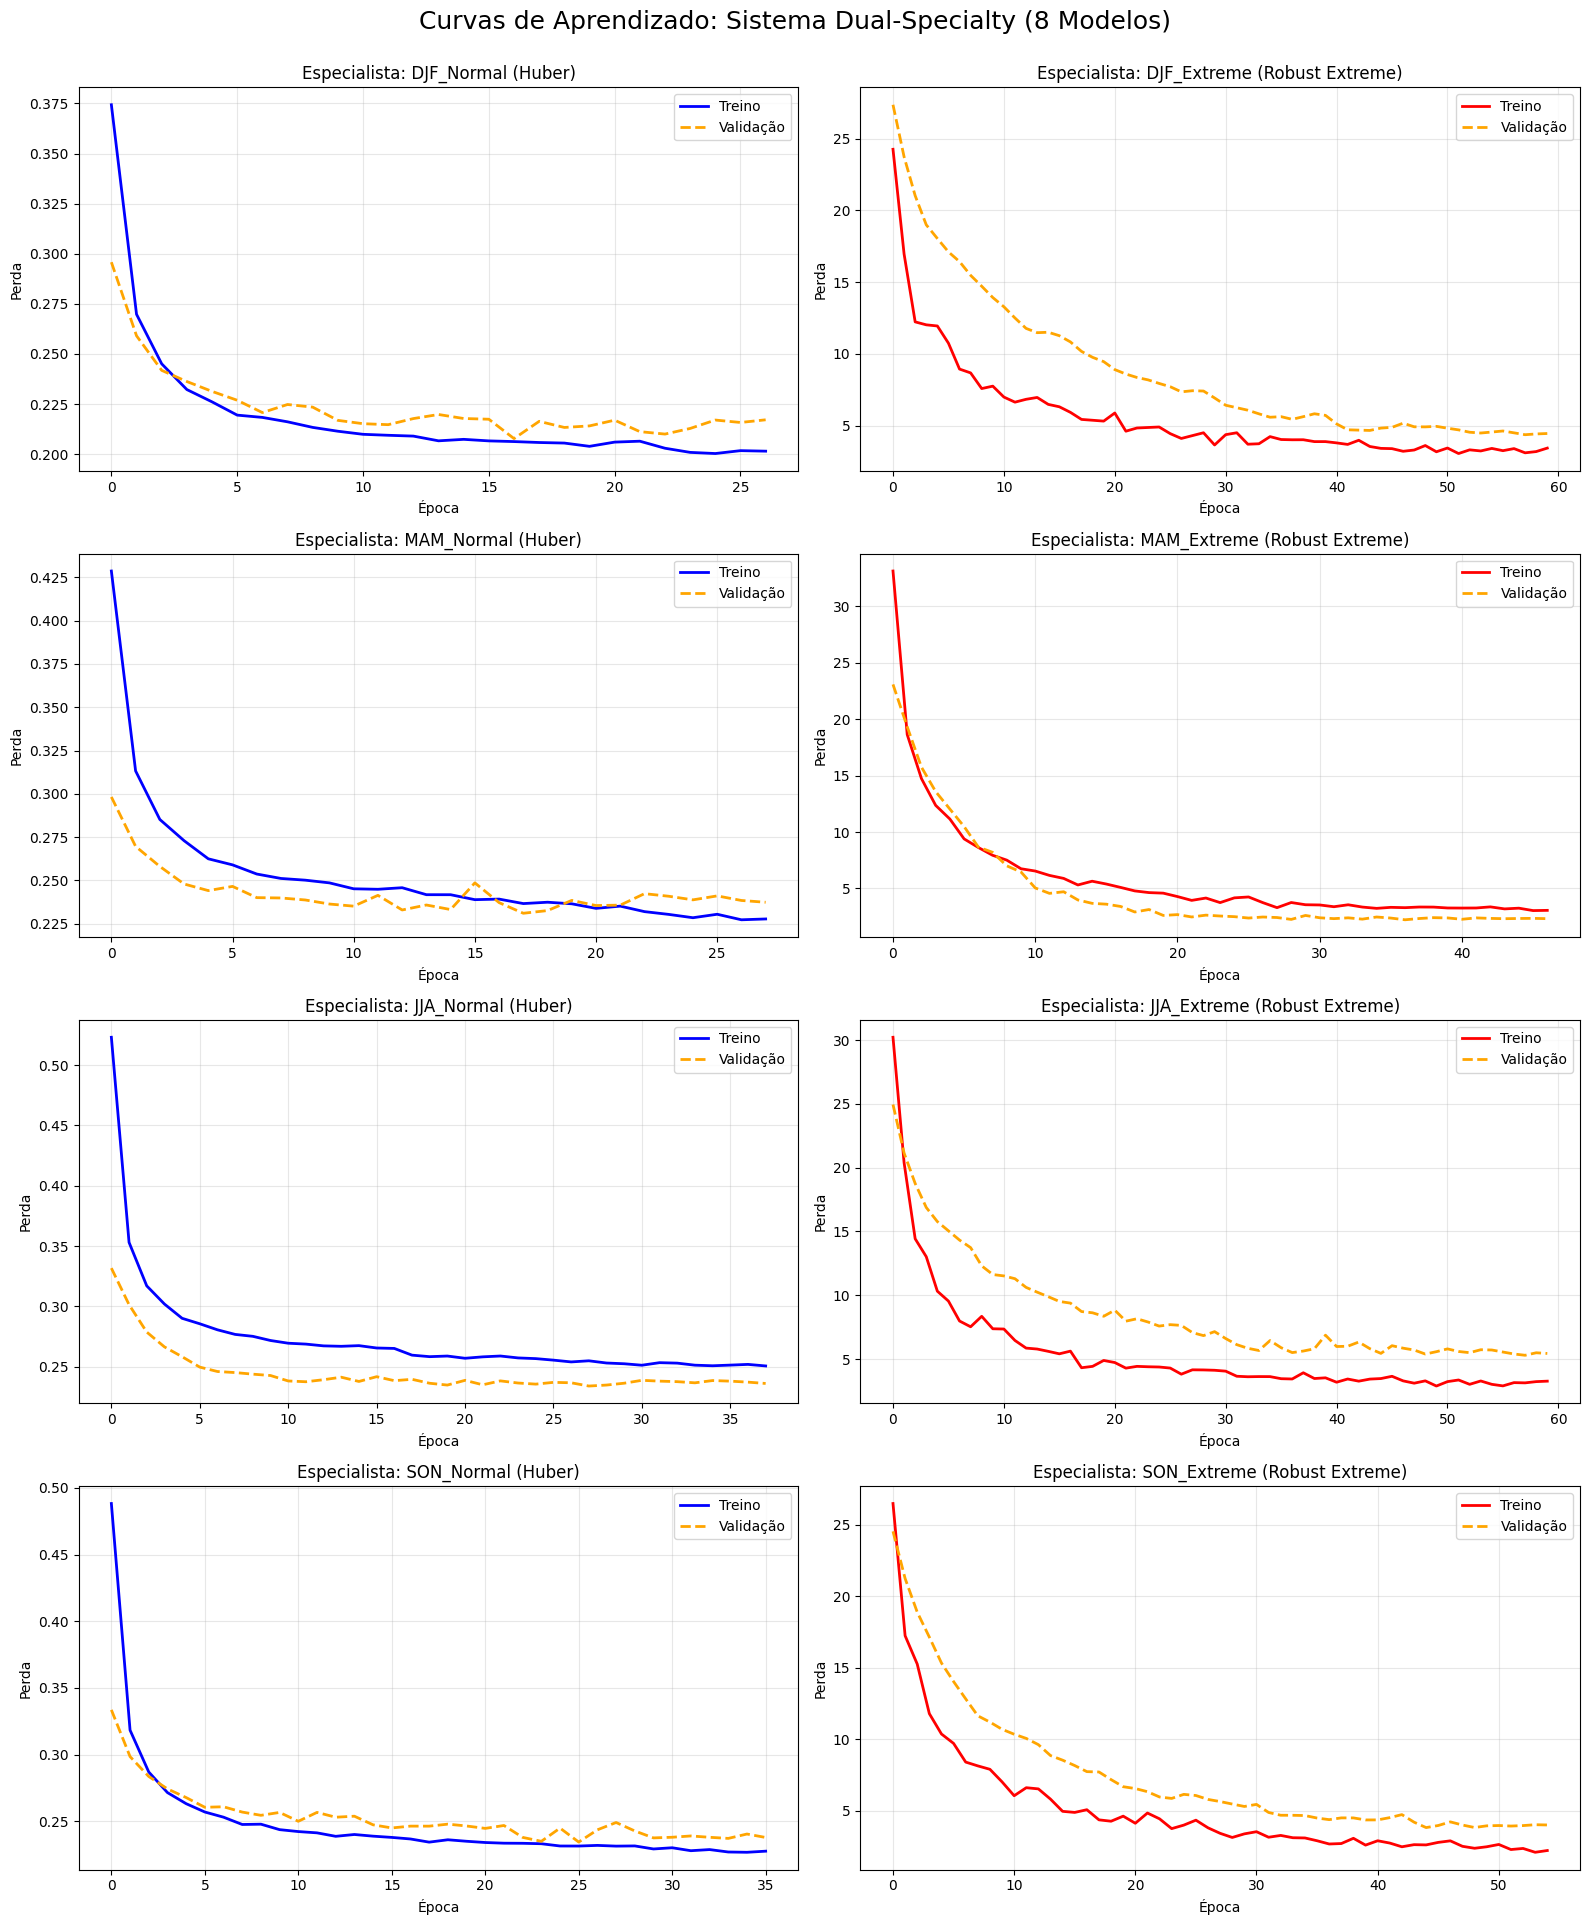

In [ ]:
import matplotlib.pyplot as plt

# Criando um grid 4x2 para os 8 especialistas
fig, axes = plt.subplots(4, 2, figsize=(16, 20), sharex=False)
seasons = ['DJF', 'MAM', 'JJA', 'SON']
specialties = ['Normal', 'Extreme']

for i, season in enumerate(seasons):
    for j, spec_type in enumerate(specialties):
        spec_name = f"{season}_{spec_type}"
        ax = axes[i, j]

        if spec_name in dual_specialty_models:
            history = dual_specialty_models[spec_name].history.history

            ax.plot(history['loss'], label='Treino', color='blue' if spec_type == 'Normal' else 'red', lw=2)
            ax.plot(history['val_loss'], label='Validação', color='orange', linestyle='--', lw=2)

            loss_name = "Huber" if spec_type == 'Normal' else "Robust Extreme"
            ax.set_title(f'Especialista: {spec_name} ({loss_name})', fontsize=12)
            ax.set_ylabel('Perda')
            ax.set_xlabel('Época')
            ax.legend()
            ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.suptitle('Curvas de Aprendizado: Sistema Dual-Specialty (8 Modelos)', fontsize=18, y=0.99)
plt.show()

### Avaliação no Teste Espacial (Estações não vistas)

Agora vamos usar o modelo para prever as rajadas nas estações de teste e comparar com os valores reais do INMET.

In [ ]:
# 1. Preparar dados de teste segmentados por estação
ds_era5_test_ens = ds_era5_daily.sel(estacao=estacoes_teste, time=test_slice)
ds_inmet_test_ens = ds_inmet.sel(estacao=estacoes_teste, time=test_slice)

# Re-preparar para garantir alinhamento com os novos modelos
X_test_s, y_test_s, clim_test_s, _, _ = prepare_lstm_seasonal(
    ds_era5_test_ens,
    ds_inmet_test_ens,
    ds_climatology
)

# 2. Pipeline de Inferência com os modelos recém-treinados
all_y_true = []
all_y_pred = []
extreme_threshold = 1.5

for season in ['DJF', 'MAM', 'JJA', 'SON']:
    if len(X_test_s[season]) == 0: continue

    X_season = X_test_s[season]
    y_true_scaled = y_test_s[season]
    clim_season = clim_test_s[season]

    y_pred_normal_scaled = dual_specialty_models[f"{season}_Normal"].predict(X_season, verbose=0)
    mask_is_extreme = (y_pred_normal_scaled > extreme_threshold).flatten()

    final_y_pred_scaled = y_pred_normal_scaled.copy()

    if np.any(mask_is_extreme):
        y_pred_extreme_scaled = dual_specialty_models[f"{season}_Extreme"].predict(X_season[mask_is_extreme], verbose=0)
        final_y_pred_scaled[mask_is_extreme] = y_pred_extreme_scaled

    y_pred_anom = s_y_s.inverse_transform(final_y_pred_scaled).flatten()
    y_true_anom = s_y_s.inverse_transform(y_true_scaled).flatten()

    y_pred_abs = y_pred_anom + clim_season
    y_true_abs = y_true_anom + clim_season

    all_y_true.extend(y_true_abs)
    all_y_pred.extend(y_pred_abs)

y_true_dual = np.array(all_y_true)
y_pred_dual = np.array(all_y_pred)

rmse_dual = np.sqrt(mean_squared_error(y_true_dual, y_pred_dual))
corr_dual = np.corrcoef(y_true_dual, y_pred_dual)[0, 1]

print(f"--- Resultado Pós-Refinamento (8 Modelos) ---")
print(f"RMSE Final: {rmse_dual:.3f} m/s")
print(f"Correlação: {corr_dual:.3f}")

mask_real_ext = y_true_dual > 12.08
if np.any(mask_real_ext):
    rmse_ext_dual = np.sqrt(mean_squared_error(y_true_dual[mask_real_ext], y_pred_dual[mask_real_ext]))
    print(f"RMSE em Extremos (>12.08 m/s): {rmse_ext_dual:.3f} m/s")

--- Resultado Pós-Refinamento (8 Modelos) ---
RMSE Final: 2.345 m/s
Correlação: 0.515
RMSE em Extremos (>12.08 m/s): 4.563 m/s


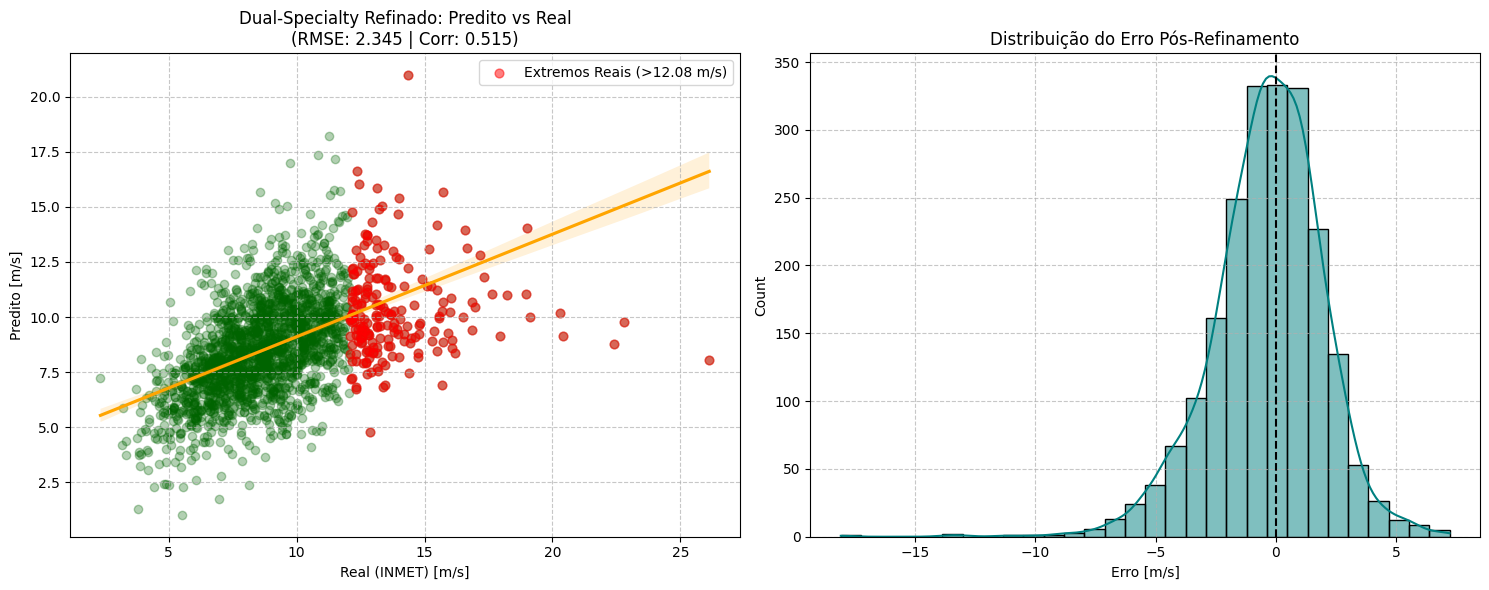

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

# 1. Scatter Plot Refinado
plt.subplot(1, 2, 1)
sns.regplot(x=y_true_dual, y=y_pred_dual,
            scatter_kws={'alpha':0.3, 'color':'darkgreen'},
            line_kws={'color':'orange'})

mask_ext = y_true_dual > 12.08
plt.scatter(y_true_dual[mask_ext], y_pred_dual[mask_ext],
            color='red', s=40, label='Extremos Reais (>12.08 m/s)', alpha=0.5)

plt.title(f'Dual-Specialty Refinado: Predito vs Real\n(RMSE: {rmse_dual:.3f} | Corr: {corr_dual:.3f})')
plt.xlabel('Real (INMET) [m/s]')
plt.ylabel('Predito [m/s]')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 2. Resíduos
plt.subplot(1, 2, 2)
errors = y_pred_dual - y_true_dual
sns.histplot(errors, kde=True, color='teal', bins=30)
plt.axvline(0, color='black', linestyle='--')
plt.title('Distribuição do Erro Pós-Refinamento')
plt.xlabel('Erro [m/s]')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()